# 04 — 8:1 RF Power Combiner

Coherently combines 8 phase-shifted element signals into one. Ideal combining gives +9 dB SNR (array gain = 20·log10(8) ≈ 18 dB in voltage).

```
8× [MTPS out] ──► [8:1 COMB] ──► RF Amp
                   ^^^^^^^^^^^
```

**Topology**: Binary tree of 2:1 resistive combiners (3 stages). Each 2:1 unit = two 100 Ω resistors → −6 dB per stage, +3 dB coherent combining.

In [1]:
import sys, os, numpy as np, matplotlib.pyplot as plt
import matplotlib; matplotlib.use('Agg')
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
try:
    NB_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    NB_DIR = os.getcwd()
_gdir = os.path.abspath(os.path.join(NB_DIR, '..', '..', 'src', 'gelochip'))
if _gdir not in sys.path: sys.path.insert(0, _gdir)
import gdsfactory as gf
from gdsfactory.component import Component
from glayout.pdk.gf180_mapped.gf180_mapped import gf180_mapped_pdk as pdk
from glayout.primitives.fet import nmos, pmos
pdk.activate()
print('gf180 PDK activated')


2026-05-11 22:31:01.788 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


gf180 PDK activated


In [2]:
import PySpice.Spice.NgSpice.RawFile as _rf
if not getattr(_rf, '_patched', False):
    _orig = _rf.RawFile._read_header
    def _p(self, s): pos=s.find(b'Circuit: '); return _orig(self,s[pos:] if pos>=0 else s)
    _rf.RawFile._read_header=_p; _rf._patched=True
print('PySpice patch applied')


PySpice patch applied


## 1. Combining Gain & Insertion Loss

- Coherent power: `P_out ∝ (N·V_in)² / (2·R_out)` — gain = 20·log10(N)
- Resistive combiner IL per 2:1 stage = 6 dB. 3 stages → 18 dB IL
- Net: +18 dB coherent − 18 dB IL = **0 dB** (no loss vs single element)
- BUT: beam direction is encoded in phase — this is beam combining, not power combining

In [3]:
N = 8
print(f'Array gain (coherent voltage): {20*np.log10(N):.1f} dB')
stages = 3
print(f'Resistive combiner IL (3 stages): {6*stages:.0f} dB')

# Friis noise contribution of combiner alone:
def db2lin(x): return 10**(x/10)
def lin2db(x): return 10*np.log10(x)
IL_db = 6.0  # each 2:1 stage
# cascading 3 stages:
F = db2lin(IL_db); G = db2lin(-IL_db)
for _ in range(2):
    F += (db2lin(IL_db)-1)/G
    G *= db2lin(-IL_db)
print(f'Combiner NF (3 stages): {lin2db(F):.1f} dB  (referred to first stage)')


Array gain (coherent voltage): 18.1 dB
Resistive combiner IL (3 stages): 18 dB
Combiner NF (3 stages): 18.0 dB  (referred to first stage)


## 2. PySpice — 2:1 Combiner AC Response

In [4]:
from PySpice.Spice.Netlist import Circuit

c = Circuit('comb_2to1')
c.SinusoidalVoltageSource('a','a',c.gnd,amplitude=1e-3)
c.SinusoidalVoltageSource('b','b',c.gnd,amplitude=1e-3)
c.R('a','a','out',100)
c.R('b','b','out',100)
c.R('l','out',c.gnd,50)

sim = c.simulator(simulator='ngspice-subprocess', ngspice_command='ngspice', temperature=25, nominal_temperature=25)
ac  = sim.ac(start_frequency=1e9, stop_frequency=1e11, number_of_points=101, variation='dec')
freq = np.array([float(f) for f in ac.frequency])
av   = 20*np.log10(np.abs(np.array(ac['out'])/np.array(ac['a'])) + 1e-30)

fig, ax = plt.subplots(figsize=(8,4))
ax.semilogx(freq/1e9, av, lw=2, color='royalblue', label='|V_out/V_a|')
ax.axvline(28, ls='--', color='red', label='28 GHz')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('Gain (dB)')
ax.set_title('2:1 Resistive Combiner — IL per stage')
ax.grid(True); ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(NB_DIR,'comb_il.png'), dpi=110); plt.show()
print(f'IL @28 GHz = {av[np.argmin(abs(freq-28e9))]:.2f} dB  (expect ≈ −6 dB)')


IL @28 GHz = -6.02 dB  (expect ≈ −6 dB)


/tmp/ipykernel_56973/40031281.py:21: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.savefig(os.path.join(NB_DIR,'comb_il.png'), dpi=110); plt.show()


## 3. GLayout — 8:1 Combiner Physical Layout

In [5]:
from core.cells.satellite_rf import rf_combiner_8to1

comb = rf_combiner_8to1(pdk)
gds_path = os.path.join(NB_DIR, 'rf_combiner_8to1.gds')
comb.write_gds(gds_path)
print('GDS written →', gds_path, '| bbox:', comb.bbox)


/tmp/ipykernel_56973/1228255034.py:5: UserWarning: Unnamed cells, 14 in 'rf_combiner_8to1'
  comb.write_gds(gds_path)
2026-05-11 22:31:05.400 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/satellite_chips/rf_combiner_8to1.gds'


GDS written → /home/irman/Gelochip/notebooks/satellite_chips/rf_combiner_8to1.gds | bbox: [[-4.6  -9.35]
 [39.   66.35]]


In [6]:
import klayout.db as kdb, klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs): print('Not found:', gds_abs); return
    out_png = gds_abs.replace('.gds','_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs,True); lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height); display(Image(out_png))
    layout=kdb.Layout(); layout.read(gds_abs)
    tc=layout.top_cell(); bb=tc.bbox(); dbu=layout.dbu
    print(f'Cell: {tc.name} | {bb.width()*dbu:.1f} µm × {bb.height()*dbu:.1f} µm | {layout.cells()} cells')


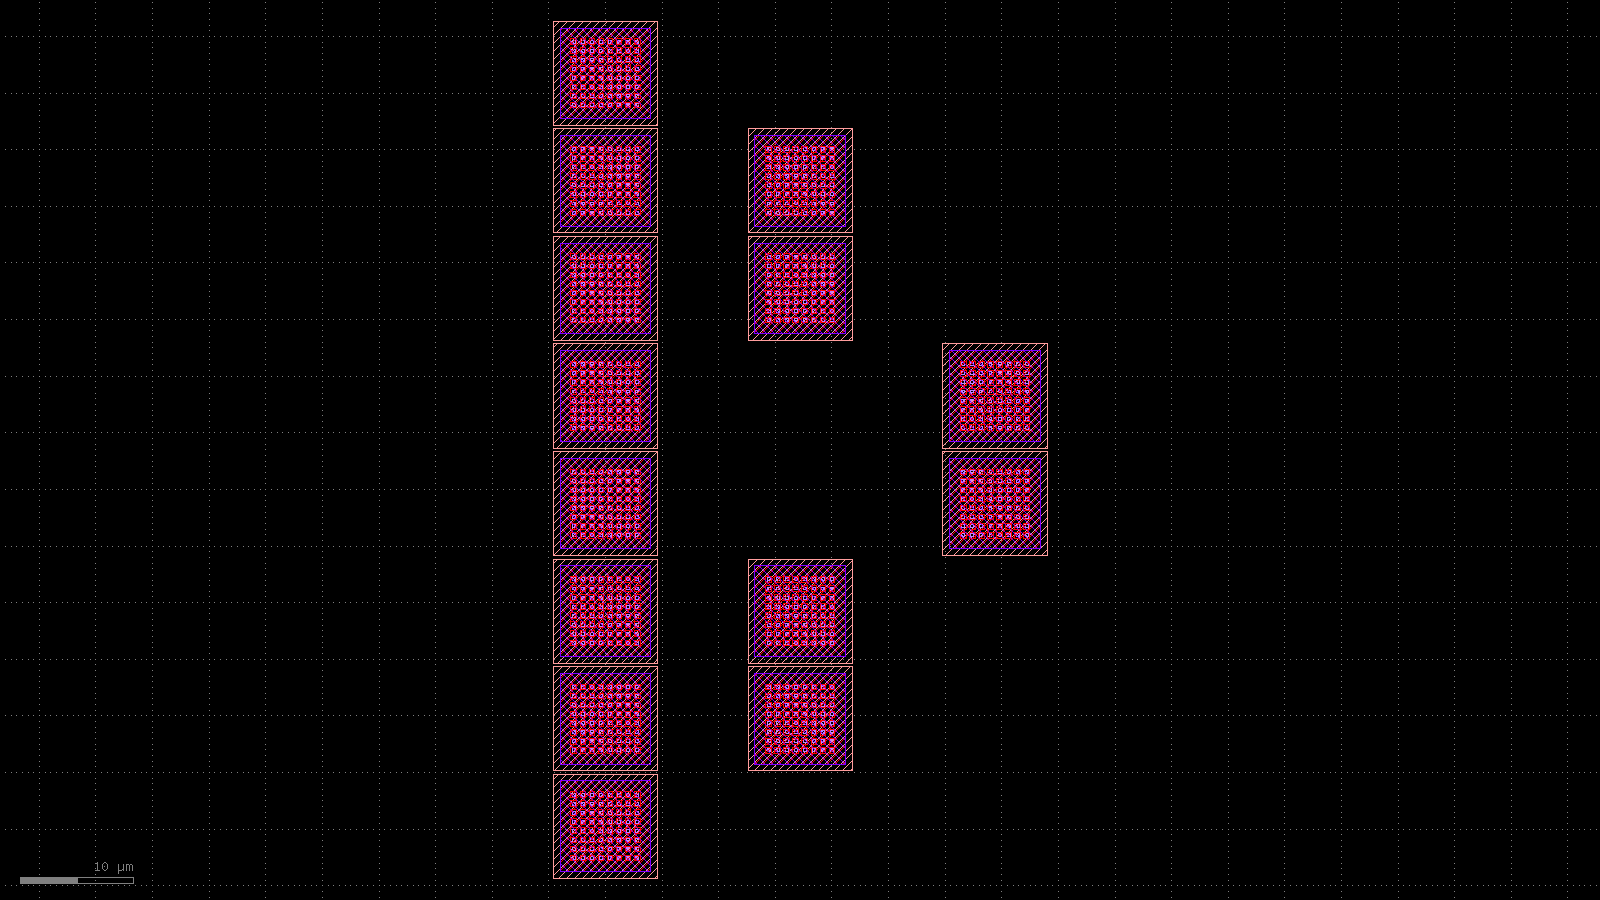

Cell: rf_combiner_8to1 | 43.6 µm × 75.7 µm | 22 cells


In [7]:
show_gds(os.path.join(NB_DIR, 'rf_combiner_8to1.gds'))


## 4. Summary

- 8:1 binary-tree combiner built from three 2:1 resistive stages.
- IL = 18 dB (3×6 dB) offset by +18 dB coherent voltage combining.
- Compact layout: fits between the 8-element MTPS bank and the post-combiner RF Amp.
- **Next →** RF Amplifier (boosts the combined signal to drive the off-chip chain).